In [35]:
import os
import glob

import numpy as np
import pandas as pd
import kagglehub

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dropout
from sympy import shape
from tensorflow.keras import layers


warnings.filterwarnings("ignore")

In [ ]:
medic = load_dataset(
    "QCRI/MEDIC",
    split="train",
    streaming=True
)

print(medic.features)

In [ ]:
crisismmd_path = kagglehub.dataset_download("shrkag/crisismmd")

annotations_path = os.path.join(
    crisismmd_path,
    "annotations"
)

annotation_files = glob.glob(
    os.path.join(annotations_path, "*_final_data.tsv")
)

print("Annotation files:", len(annotation_files))

In [ ]:
crisismmd_df = pd.concat(
    [
        pd.read_csv(file, sep="\t")
        for file in annotation_files
    ],
    ignore_index=True
)

print("CrisisMMD rows:", len(crisismmd_df))
print("CrisisMMD columns:")
print(crisismmd_df.columns.tolist())

In [ ]:
crisismmd_text_lookup = (
    crisismmd_df[
        ["image_id", "tweet_text"]
    ]
    .drop_duplicates("image_id")
    .set_index("image_id")["tweet_text"]
    .to_dict()
)

print("Unique CrisisMMD image IDs:", len(crisismmd_text_lookup))

In [ ]:
matched_rows = []

for item in medic:

    filename = os.path.basename(item["image_path"])
    medic_image_id = os.path.splitext(filename)[0]

    if medic_image_id in crisismmd_text_lookup:

        matched_rows.append({
            "image_id": medic_image_id,
            "tweet_text": crisismmd_text_lookup[medic_image_id],
            "image_path": item["image_path"],
            "damage_severity": item["damage_severity"],
            "disaster_types": item["disaster_types"]
        })

print("Matched samples:", len(matched_rows))

In [ ]:
matched_df = pd.DataFrame(matched_rows)

print("Shape:", matched_df.shape)
matched_df.head()

print("Rows:", len(matched_df))
print("Unique images:", matched_df["image_id"].nunique())

print("\nMissing values:")
print(matched_df.isnull().sum())

print("\nDuplicate image IDs:")
print(matched_df["image_id"].duplicated().sum())


print(
    matched_df["damage_severity"]
    .value_counts()
    .sort_index()
)


severity_percentages = (
    matched_df["damage_severity"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(severity_percentages.round(2))

In [ ]:
for severity in sorted(matched_df["damage_severity"].unique()):

    print("\n" + "=" * 60)
    print("Severity:", severity)
    print("=" * 60)

    samples = matched_df[
        matched_df["damage_severity"] == severity
    ]["tweet_text"].sample(
        min(5, (matched_df["damage_severity"] == severity).sum()),
        random_state=42
    )

    for tweet in samples:
        print("-", tweet)


matched_df["tweet_length"] = matched_df["tweet_text"].str.len()

print(matched_df["tweet_length"].describe())


print(
    matched_df.groupby("damage_severity")["tweet_length"]
    .describe()
)


matched_df = matched_df.drop(columns=["tweet_length"])

In [ ]:
severity_by_disaster = pd.crosstab(
    matched_df["disaster_types"],
    matched_df["damage_severity"]
)

print(severity_by_disaster)


severity_by_disaster_percent = pd.crosstab(
    matched_df["disaster_types"],
    matched_df["damage_severity"],
    normalize="index"
) * 100

print(severity_by_disaster_percent.round(2))

In [ ]:
train_df, temp_def = train_test_split(
    matched_df,
    test_size=0.3,
    stratify=matched_df['damage_severity'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_def,
    test_size=0.5,
    stratify=temp_def['damage_severity'],
    random_state=42
)

classes = np.unique(train_df['damage_severity'])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['damage_severity']
)

print("Class Weights:", weights)

In [ ]:
X_train_text = train_df["tweet_text"]
y_train = train_df["damage_severity"]

X_val_text = val_df["tweet_text"]
y_val = val_df["damage_severity"]

X_test_text = test_df["tweet_text"]
y_test = test_df["damage_severity"]


print("Training texts:", len(X_train_text))
print("Validation texts:", len(X_val_text))
print("Test texts:", len(X_test_text))

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_val_tfidf = tfidf.transform(X_val_text)

X_test_tfidf = tfidf.transform(X_test_text)


print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Naive Byes": MultinomialNB()
}


results = []

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=1000
        )),
        ("classifier", model)
    ])

    accuracy = cross_val_score(
        pipe,
        X_train_text,
        y_train,
        cv=3,
        scoring="accuracy"
    )

    macro_f1 = cross_val_score(
        pipe,
        X_train_text,
        y_train,
        cv=3,
        scoring="f1_macro"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy.mean(),
        "Macro_F1": macro_f1.mean()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("Macro_F1", ascending=False))

In [ ]:
# ANN - Artificial Neural Networks

X_train_ann = X_train_tfidf.toarray()

X_val_ann = X_val_tfidf.toarray()

X_test_ann = X_test_tfidf.toarray()

class_weights = {
    0: 0.42945368,
    1: 6.26327945,
    2: 1.95389049
}


ann_model = keras.Sequential([
    layers.Input(shape=(X_train_ann.shape[1],)),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = ann_model.fit(
    X_train_ann,
    y_train,
    validation_data=(X_val_ann, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)


ann_predictions = ann_model.predict(
    X_val_ann,
    verbose=0
).argmax(axis=1)

ann_accuracy = accuracy_score(
    y_val,
    ann_predictions
)

ann_macro_f1 = f1_score(
    y_val,
    ann_predictions,
    average="macro"
)

print("ANN Accuracy:", ann_accuracy)
print("ANN Macro F1:", ann_macro_f1)

In [ ]:
validation_results = []

for name, model in models.items():

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=10000
        )),
        ("classifier", model)
    ])

    pipe.fit(X_train_text, y_train)

    predictions = pipe.predict(X_val_text)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })


# Add ANN only once, AFTER the loop
validation_results.append({
    "Model": "ANN",
    "Accuracy": ann_accuracy,
    "Macro_F1": ann_macro_f1
})


# Convert list to DataFrame
validation_results_df = pd.DataFrame(validation_results)


# Sort by Macro F1
print(
    validation_results_df
    .sort_values("Macro_F1", ascending=False)
    .to_string(index=False)
)

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words='english'
    )),


    (
        "classifier", LogisticRegression(
            class_weight=class_weights,
            max_iter=2000,
            random_state=42
        )
    )
])

lr_param_grid = {
    "tfidf__max_features": [5000, 10000, 15000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__sublinear_tf": [True, False],
    "classifier__C": [0.1, 0.5, 1, 2, 5, 10]
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


lr_search.fit(X_train_text, y_train)

print("Best Logistic Regression parameters:")
print(lr_search.best_params_)

print("\nBest CV Macro F1:")
print(lr_search.best_score_)

lr_val_predictions = lr_search.best_estimator_.predict(X_val_text)

lr_val_accuracy = accuracy_score(
    y_val,
    lr_val_predictions
)

lr_val_macro_f1 = f1_score(
    y_val,
    lr_val_predictions,
    average="macro"
)

print("Tuned Logistic Regression")
print("Validation Accuracy:", lr_val_accuracy)
print("Validation Macro F1:", lr_val_macro_f1)

In [ ]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words='english'
    )),

    ("classifier", LinearSVC(
        class_weight=class_weights,
        random_state=42
    ))
])

svm_param_grid = {
    "tfidf__max_features": [5000, 10000, 15000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__sublinear_tf": [True, False],
    "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}


svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


svm_search.fit(X_train_text, y_train)

svm_val_predictions = svm_search.best_estimator_.predict(X_val_text)

svm_val_accuracy = accuracy_score(
    y_val,
    svm_val_predictions
)

svm_val_macro_f1 = f1_score(
    y_val,
    svm_val_predictions,
    average="macro"
)

print("Tuned Linear SVM")
print("Validation Accuracy:", svm_val_accuracy)
print("Validation Macro F1:", svm_val_macro_f1)

Final Text Model: Tuned Linear SVM
Test Accuracy: 0.7293577981651376
Test Macro F1: 0.4730877437444916
                  precision    recall  f1-score   support

Little/No Damage       0.86      0.82      0.84      1354
     Mild Damage       0.14      0.13      0.14        92
   Severe Damage       0.40      0.49      0.44       298

        accuracy                           0.73      1744
       macro avg       0.47      0.48      0.47      1744
    weighted avg       0.74      0.73      0.73      1744



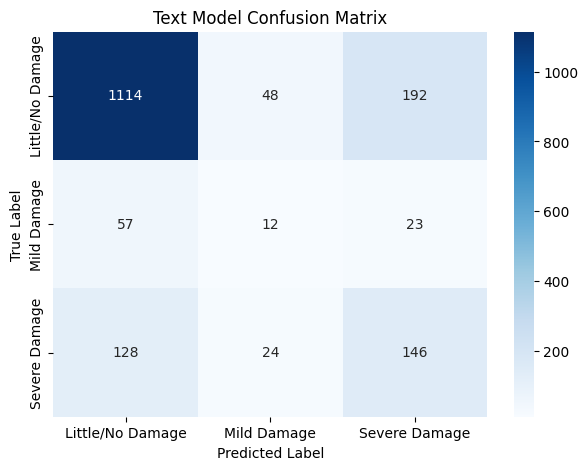

In [36]:
final_svm = svm_search.best_estimator_

test_predictions = final_svm.predict(X_test_text)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average='macro'
)

print("Final Text Model: Tuned Linear SVM")
print("Test Accuracy:", test_accuracy)
print("Test Macro F1:", test_macro_f1)


print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Little/No Damage",
            "Mild Damage",
            "Severe Damage"
        ]
    )
)

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Little/No Damage",
        "Mild Damage",
        "Severe Damage"
    ],
    yticklabels=[
        "Little/No Damage",
        "Mild Damage",
        "Severe Damage"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Text Model Confusion Matrix")

plt.show()